# Image Understanding with BLIP

This notebook demonstrates image captioning using the BLIP model from Hugging Face Transformers.

## Goal
- Load the required libraries
- Detect available hardware
- Load the BLIP processor and model
- Open and display an image
- Generate a caption for the image

## Import Required Libraries

This section imports all libraries needed for image handling, plotting, PyTorch, and BLIP model usage.

In [ ]:
# Basic Libraries
from PIL import Image
import matplotlib.pyplot as plt

# PyTorch
import torch

# Hugging Face Transformers
from transformers import BlipProcessor
from transformers import BlipForConditionalGeneration
from transformers import BlipForQuestionAnswering

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## Configure Device

PyTorch is used to check whether a GPU is available.  
If CUDA is available, the model will run on the GPU; otherwise, it will run on the CPU.

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using Device : {device}")

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using Device : cuda
NVIDIA GeForce RTX 4060 Laptop GPU


## Load BLIP Processor and Model

The BLIP processor prepares the image for the model and the captioning model generates the final description.

In [3]:
processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-large",
    cache_dir = "./model"
)

caption_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-large",
    cache_dir = "./model"
).to(device)

caption_model.eval()

print("BLIP Large Model Loaded Successfully!")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


BLIP Large Model Loaded Successfully!


# Load BLIP VQA Model
Load the BLIP processor and VQA base model for visual question answering, move to the device, and set to evaluation mode.

In [4]:
vqa_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-vqa-base",
    cache_dir="./model"
)

vqa_model = BlipForQuestionAnswering.from_pretrained(
    "Salesforce/blip-vqa-base",
    cache_dir="./model"
).to(device)

vqa_model.eval()
print("BLIP VQA Base Model Loaded Successfully!")

BLIP VQA Base Model Loaded Successfully!


# Open and Display an Image
Open the example image, convert to RGB, and display it using matplotlib for visual inspection.

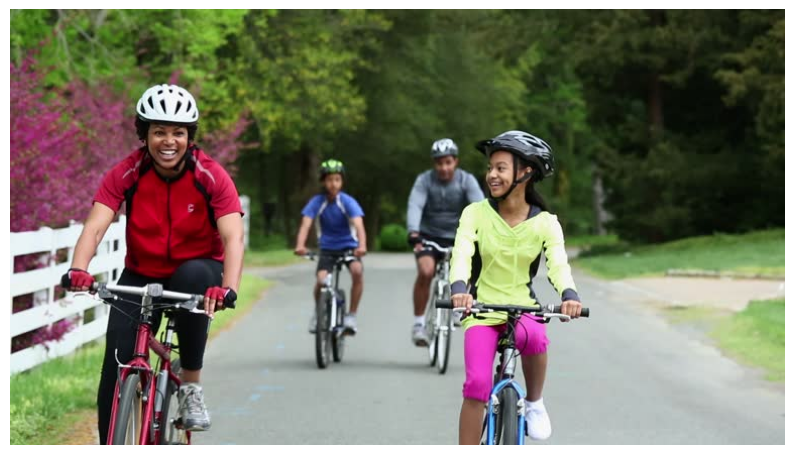

In [5]:
image_path = "test_images/ridingbicycle.jpg"

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(10,8))
plt.imshow(image)
plt.axis("off")
plt.show()

# Generate a Caption for the Image
Prepare model inputs from the image, run the captioning model with beam search, and decode the generated caption.

In [6]:
inputs = processor(
    image,
    return_tensors="pt"
)

inputs = {
    k: v.to(device)
    for k, v in inputs.items()
}

with torch.no_grad():

    output = caption_model.generate(
        **inputs,
        max_length=100,
        min_length=20,
        num_beams=7,
        repetition_penalty=1.2,
        early_stopping=True,
        return_dict_in_generate=True,
        output_scores=True
    )

caption = processor.decode(
    output.sequences[0],
    skip_special_tokens=True
)

print("Generated Caption:")
print(caption)

Generated Caption:
group of people riding bikes down a paved road next to a white fence with purple flowers in the background


# Compute Caption Confidence & Reliability
Compute per-step softmax-based confidence scores from generation logits, aggregate to a single reliability score, and print a human-readable reliability level.

In [7]:
confidence_scores = []

for score in output.scores:
    probabilities = torch.softmax(score, dim=-1)
    max_probability = probabilities.max().item()
    confidence_scores.append(max_probability)

if len(confidence_scores) > 0:
    confidence = sum(confidence_scores) / len(confidence_scores)

else:
    confidence = 0.0

print(f"Confidence Score : {confidence * 100:.2f}%")

if confidence >= 0.90:
    level = "Very High"

elif confidence >= 0.80:
    level = "High"

elif confidence >= 0.70:
    level = "Moderate"

else:
    level = "Low"

print(f"Reliability      : {level}")

Confidence Score : 70.41%
Reliability      : Moderate


# Caption Generation Helper Function
Define generate_caption(image_path) to encapsulate preprocessing, model generation, decoding, and confidence computation — returns (caption, confidence).

In [8]:
def generate_caption(image_path):

    image = Image.open(image_path).convert("RGB")

    inputs = processor(
        image,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():

        output = caption_model.generate(
            **inputs,
            max_length=100,
            min_length=20,
            num_beams=7,
            repetition_penalty=1.2,
            early_stopping=True,
            return_dict_in_generate=True,
            output_scores=True
        )

    caption = processor.decode(
        output.sequences[0],
        skip_special_tokens=True
    )

    confidence_scores = []

    for score in output.scores:

        probability = torch.softmax(score, dim=-1)

        confidence_scores.append(
            probability.max().item()
        )

    confidence = (
        sum(confidence_scores) / len(confidence_scores)
        if confidence_scores
        else 0.0
    )

    return caption, confidence

# Visual Question Answering Helper Function
Define ask_question(image_path, question) to preprocess image+question, generate an answer with the VQA model, decode it, and compute a confidence score.

In [9]:
def ask_question(image_path, question):

    image = Image.open(image_path).convert("RGB")

    inputs = vqa_processor(
        image,
        question,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():

        output = vqa_model.generate(
            **inputs,
            max_length=30,
            return_dict_in_generate=True,
            output_scores=True
        )

    answer = vqa_processor.decode(
        output.sequences[0],
        skip_special_tokens=True
    )

    confidence_scores = []

    for score in output.scores:

        probability = torch.softmax(score, dim=-1)

        confidence_scores.append(
            probability.max().item()
        )

    confidence = (
        sum(confidence_scores) / len(confidence_scores)
        if confidence_scores
        else 0.0
    )

    return answer, confidence

# Run Multiple VQA Queries
Define a list of example questions to ask about the image and loop through them, printing each question with its predicted answer and confidence.

In [10]:
image_path = "test_images/ridingbicycle.jpg"

questions = [

    "How many people are riding bicycles?",
    "What are the people doing?",
    "Are the people wearing helmets?",
    "Is this outdoors or indoors?",
    "What color is the girl's pants in the front?",
    "What color is the woman's shirt on the left?",
    "Is there a road in the image?",
    "Are there trees in the background?",
    "How many children are visible?",
    "Is everyone riding a bicycle?"

]

for question in questions:

    answer, confidence = ask_question(
        image_path,
        question
    )

    print("Question  :", question)
    print("Answer    :", answer)
    print(f"Confidence: {confidence*100:.2f}%")

Question  : How many people are riding bicycles?
Answer    : 5
Confidence: 71.39%
Question  : What are the people doing?
Answer    : riding bikes
Confidence: 65.77%
Question  : Are the people wearing helmets?
Answer    : yes
Confidence: 88.52%
Question  : Is this outdoors or indoors?
Answer    : outdoors
Confidence: 88.87%
Question  : What color is the girl's pants in the front?
Answer    : pink
Confidence: 88.60%
Question  : What color is the woman's shirt on the left?
Answer    : yellow
Confidence: 67.36%
Question  : Is there a road in the image?
Answer    : yes
Confidence: 89.14%
Question  : Are there trees in the background?
Answer    : yes
Confidence: 89.48%
Question  : How many children are visible?
Answer    : 3
Confidence: 58.55%
Question  : Is everyone riding a bicycle?
Answer    : yes
Confidence: 79.03%


# Save Pipeline to File
Write a small pipeline.py that loads processors and models and exposes them in a pipeline dictionary for reuse in other scripts.

In [11]:
%%writefile pipeline.py

import torch

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    BlipForQuestionAnswering,
)

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Caption Model
processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-large",
    cache_dir="./model"
)

caption_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-large",
    cache_dir="./model"
).to(device)

# VQA Model
vqa_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-vqa-base",
    cache_dir="./model"
)

vqa_model = BlipForQuestionAnswering.from_pretrained(
    "Salesforce/blip-vqa-base",
    cache_dir="./model"
).to(device)

pipeline = {
    "device": device,
    "processor": processor,
    "caption_model": caption_model,
    "vqa_processor": vqa_processor,
    "vqa_model": vqa_model
}

Overwriting pipeline.py
